In [1]:
# Preliminaries -----------------------------------------------------------
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, haven)

library(knitr)
library(kableExtra)

Loading required package: pacman


Attaching package: ‘kableExtra’


The following object is masked from ‘package:dplyr’:

    group_rows




In [2]:
hcris.full <- read_tsv("../data/output/HCRIS_Data.txt")

Rows: 161060 Columns: 44
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr   (9): provider_number, data_source, street, city, state, zip, county, n...
dbl  (31): beds, tot_charges, net_pat_rev, tot_discounts, tot_operating_exp,...
date  (4): fy_start, fy_end, date_processed, date_created

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
# price for each hospital-year
price.filtered.hcris <- hcris.full %>% 
  mutate(
    discount_factor = 1-tot_discounts/tot_charges,
    price_num = (ip_charges + icu_charges + ancillary_charges)*discount_factor - tot_mcare_payment,
    price_denom = tot_discharges - mcare_discharges,
    est_price = price_num/price_denom
  ) %>% 
  mutate(est_price = ifelse(est_price < 0, NA, est_price)) %>% # setting nans for negative prices
  mutate(
    p99 = quantile(est_price, 0.99, na.rm = TRUE), # clear outliers
    p01 = quantile(est_price, 0.01, na.rm = TRUE),
    est_price = ifelse(est_price < p01 | est_price > p99, NA, est_price)) %>% 
  drop_na(est_price) %>%
  select(-p99, -p01) %>%
  mutate(
    hvbp_payment = ifelse(is.na(hvbp_payment), 0, hvbp_payment),
    hrrp_payment = ifelse(is.na(hrrp_payment), 0, abs(hrrp_payment))
  )

# 2012 penalize, change in definition of net penalty
net_penalty <- price.filtered.hcris %>% 
  filter(year == 2012) %>% 
  mutate(net_penalty = hvbp_payment - hrrp_payment) %>% 
  select(provider_number, net_penalty)

# from 2011 until 2014
price_change <- price.filtered.hcris %>% 
  filter(year %in% c(2011, 2014)) %>% 
  select(provider_number, year, est_price) %>% 
  pivot_wider(names_from = year, values_from = est_price, names_prefix = "price_") %>% 
  mutate(price_change = price_2014 - price_2011) %>% 
  select(provider_number, price_change)

# averages before 2012 from 2009-2011
pre_2012 <- price.filtered.hcris %>%
  filter(year %in% c(2009:2011)) %>%
  group_by(provider_number) %>%
  summarize(
    mean_mcare = mean(mcare_discharges, na.rm = TRUE),
    mean_beds = mean(beds, na.rm = TRUE),
    mean_mcaid = mean(mcaid_discharges, na.rm = TRUE)
  ) %>% ungroup()

# combined set
merged_data <- price_change %>% 
  inner_join(net_penalty, by = "provider_number") %>% 
  inner_join(pre_2012, by = "provider_number") %>% 
  filter (!is.na(price_change), !is.na(net_penalty), 
     !is.na(mean_mcare),!is.na(mean_mcaid))  

price.filtered.hcris %>% 
  filter(source =="weighted_average")

provider_number,fy_start,fy_end,date_processed,date_created,data_source,beds,tot_charges,net_pat_rev,tot_discounts,⋯,tot_uncomp_care_charges,tot_uncomp_care_partial_pmts,bad_debt,accum_dep,year,source,discount_factor,price_num,price_denom,est_price
<chr>,<date>,<date>,<date>,<date>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
010012,2023-04-01,2024-12-31,2025-06-06,2025-06-03,NA,97,446571221,NA,402098504,⋯,NA,NA,NA,NA,2024,weighted_average,0.09958706,8570724,1929.5399,4441.848
010016,2009-10-01,2010-12-31,2011-06-28,2011-02-25,NA,192,657038543,NA,543336407,⋯,NA,NA,NA,NA,2010,weighted_average,0.17305246,41382868,5900.2000,7013.808
010024,2009-07-01,2010-12-31,2014-10-22,2011-01-25,NA,255,500669906,NA,369702330,⋯,NA,NA,NA,NA,2010,weighted_average,0.26158468,42407698,6660.7660,6366.790
010034,2002-07-01,2003-09-30,2005-03-15,2004-10-13,NA,69,25572712,NA,10085749,⋯,NA,NA,NA,NA,2003,weighted_average,0.60560502,2042364,799.2000,2555.511
010038,2016-07-01,2017-09-30,2018-11-14,2018-03-20,NA,125,344555341,NA,316067599,⋯,NA,NA,NA,NA,2017,weighted_average,0.08267973,2778964,1024.9011,2711.446
010046,2014-07-01,2015-12-31,2016-07-25,2015-10-23,NA,256,760393609,NA,683837396,⋯,NA,NA,NA,NA,2015,weighted_average,0.10067972,19684065,2897.1920,6794.187
010054,2010-07-01,2011-12-31,2014-07-23,2013-11-12,NA,109,240108319,NA,203712711,⋯,NA,NA,NA,NA,2011,weighted_average,0.15157995,8975795,1949.8208,4603.395
010055,2013-07-01,2014-09-30,2015-03-20,2014-12-17,NA,235,993595674,NA,828984910,⋯,NA,NA,NA,NA,2014,weighted_average,0.16567178,42002988,5123.8000,8197.624
010059,2008-03-01,2009-09-30,2013-06-07,2010-04-07,NA,37,39132994,NA,25277986,⋯,NA,NA,NA,NA,2009,weighted_average,0.35404928,1181498,702.4419,1681.987


Upon dataset creation, prices were calculated using hospital cost report variables where negative prices were dropped, and top & bottom 1% outliers were removed. This was then used to curate data to answer questions for estimating ATEs. Price changes from 2011 through 2014 resulted from a simple difference between the two years; the net penalty was the same, with a difference between HVBP and HRRP payments. All these were reported alongside mean numbers for pre-period Medicare discharges, bed size, and Medicaid discharges from 2009 to 2011.

## Problem 1

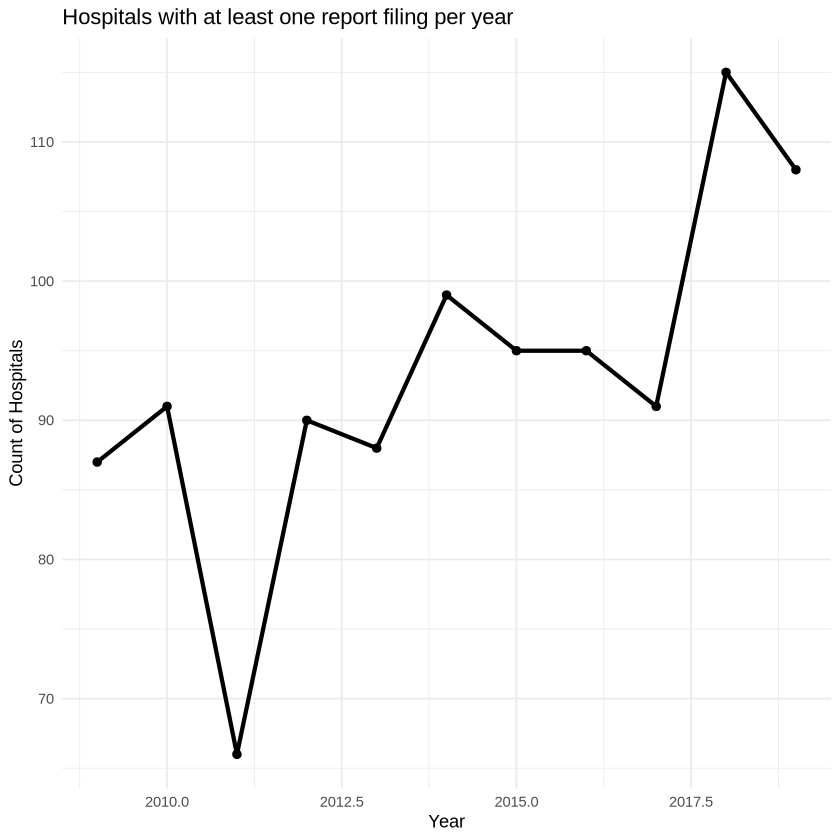

In [4]:
dup.count <- hcris.full %>% 
  group_by(source, year) %>% 
  filter((source == "total for year")|(source == "weighted_average"))%>%
  group_by(year) %>% 
  summarize("frequency" = n()) %>% 
  filter(year >= 2009, year <= 2019)

dup.count %>%
  ggplot(aes(x = year, y = frequency)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 2) +
  labs(
    x = "Year",
    y = "Count of Hospitals",
    title = "Hospitals with at least one report filing per year"
  ) +
  theme_minimal()

The number of hospitals filing more than one report is noticeable and varies over the years.

## Problem 2

In [5]:
hcris.full %>%
  mutate(year = year(fy_end)) %>%
  filter(year >= 2009, year <= 2019) %>%
  group_by(year) %>%
  summarise(unique_hospitals = n_distinct(provider_number)) %>%
  kable(
    col.names = c("Year", "Unique Hospitals"),
    digits    = 0,
    booktabs  = TRUE,
    row.names = FALSE,
    caption   = "Number of Unique Hospitals per Year (2009–2019)"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>Number of Unique Hospitals per Year (2009–2019)</caption>
 <thead>
  <tr>
   <th style="text-align:right;font-weight: bold;"> Year </th>
   <th style="text-align:right;font-weight: bold;"> Unique Hospitals </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2009 </td>
   <td style="text-align:right;"> 6100 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2010 </td>
   <td style="text-align:right;"> 6103 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2011 </td>
   <td style="text-align:right;"> 6097 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2012 </td>
   <td style="text-align:right;"> 6140 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2013 </td>
   <td style="text-align:right;"> 6066 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2014 </td>

After removing/combining multiple reports, the number of unique hospital IDs (Medicare provider numbers) is about 6000 in the data.

## Problem 3

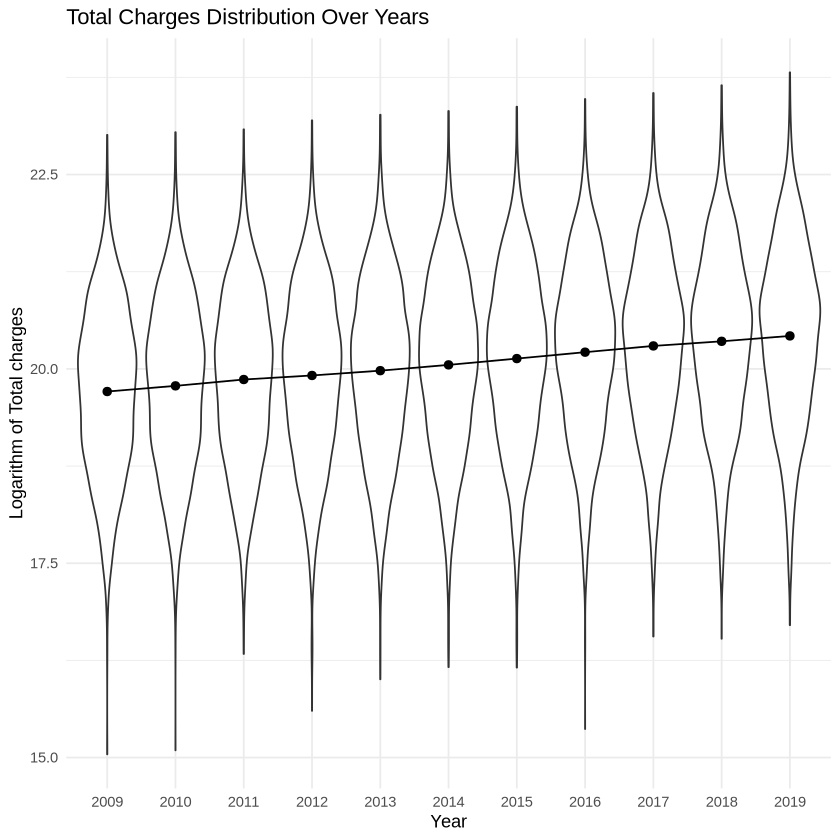

In [6]:
price.filtered.hcris %>%
  mutate(year = year(fy_end)) %>%
  filter(year >= 2009, year <= 2019) %>%
  filter(tot_charges > 0) %>%
  ggplot(aes(x = factor(year), y = log(tot_charges))) +
  geom_violin() +
  stat_summary(fun = "mean", geom = "point", color = "black", size = 2) +
  stat_summary(fun = "mean", geom = "line", aes(group = 1), color = "black") +
  labs(
    title = "Total Charges Distribution Over Years",
    x = "Year",
    y = "Logarithm of Total charges"
  ) +
  theme_minimal()

From 2009-2019, the distribution of total charges (tot_charges in the data) in each year is increasing, as can be seen. Note, the log y-axis scale has been implemented to capture standardized, prominent effects.

## Problem 4

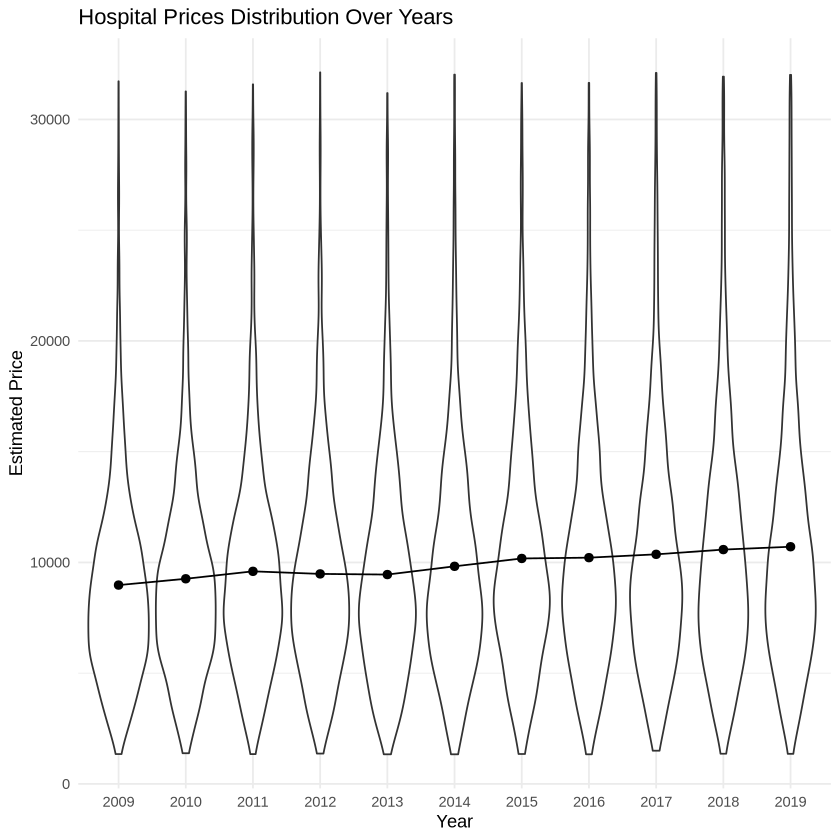

In [7]:
price.filtered.hcris %>%
  mutate(
    year = year(fy_end),
    discount_factor = 1 - tot_discounts / tot_charges,
    price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
    price_denom = tot_discharges - mcare_discharges,
    price = price_num / price_denom
  ) %>%
  filter(year >= 2009, year <= 2019) %>%
  ggplot(aes(x = factor(year), y = est_price)) +
  geom_violin() +
  stat_summary(fun = "mean", geom = "point", color = "black", size = 2) +
  stat_summary(fun = "mean", geom = "line", aes(group = 1), color = "black") +
  labs(
    title = "Hospital Prices Distribution Over Years",
    x = "Year",
    y = "Estimated Price"
  ) +
  theme_minimal()

From 2009-2019, the distribution of estimated prices in each year has again been mildly increasing, approaching the $10,000 mark.

## Problem 5

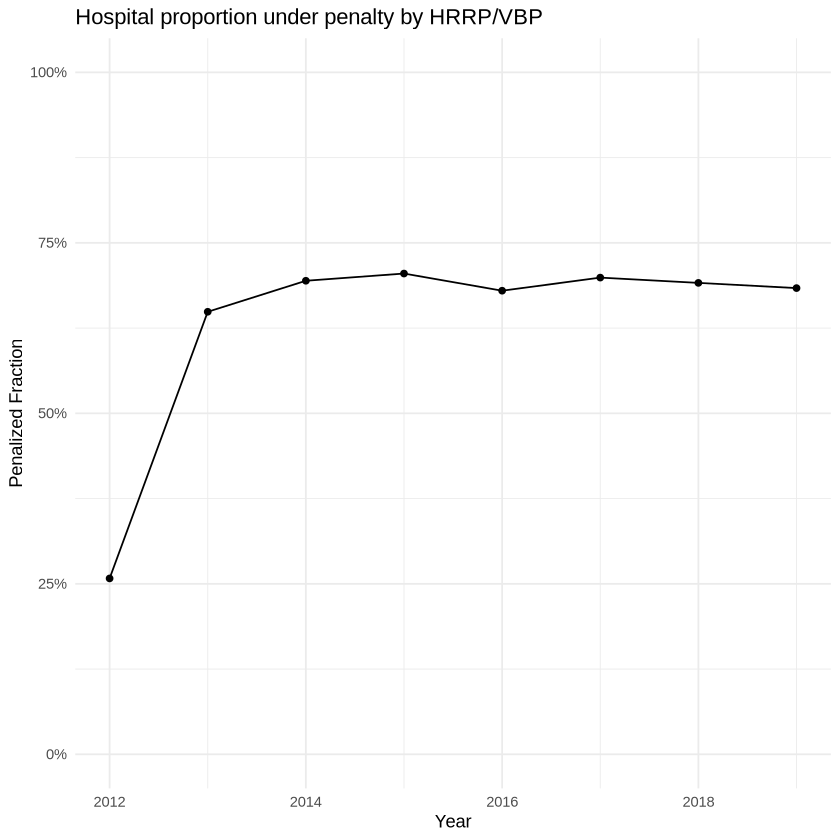

In [8]:
price.filtered.hcris %>%
  mutate(
    year = year(fy_end),
    penalty = as.numeric((hvbp_payment - hrrp_payment) < 0)
  ) %>%
  filter(year >= 2012, year <= 2019) %>%
  group_by(year) %>%
  summarise(share_penalty = mean(penalty, na.rm = TRUE)) %>%
  
ggplot(aes(x = year, y = share_penalty)) +
  geom_line() +
  geom_point() +
  scale_y_continuous(labels = scales::percent, limits = c(0, 1)) +
  labs(
    title = "Hospital proportion under penalty by HRRP/VBP",
    x = "Year",
    y = "Penalized Fraction"
  ) +
  theme_minimal()

The proportion of hospitals under penalty by HRRP/VBP stays relatively at the same level of apprximately 70% throughout the majority of years.

## Problem 6

In [9]:
ols1 <- lm(price_change ~ net_penalty, data = merged_data)
ols2 <- lm(price_change ~ net_penalty + mean_beds, data = merged_data)
ols3 <- lm(price_change ~ net_penalty + mean_beds + mean_mcaid, data = merged_data)

summary(ols1)
summary(ols2)
summary(ols3)


Call:
lm(formula = price_change ~ net_penalty, data = merged_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-21475.3  -1238.8    -68.8   1204.7  21761.2 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 219.448177  55.195425   3.976 7.22e-05 ***
net_penalty  -0.003633   0.001357  -2.678  0.00747 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2625 on 2391 degrees of freedom
Multiple R-squared:  0.002989,	Adjusted R-squared:  0.002572 
F-statistic: 7.169 on 1 and 2391 DF,  p-value: 0.007468



Call:
lm(formula = price_change ~ net_penalty + mean_beds, data = merged_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-21464.0  -1231.0    -66.2   1196.7  21753.7 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 201.422961  55.773506   3.611 0.000311 ***
net_penalty  -0.003534   0.001356  -2.605 0.009239 ** 
mean_beds     0.074253   0.034188   2.172 0.029961 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2623 on 2390 degrees of freedom
Multiple R-squared:  0.004953,	Adjusted R-squared:  0.004121 
F-statistic: 5.949 on 2 and 2390 DF,  p-value: 0.002648



Call:
lm(formula = price_change ~ net_penalty + mean_beds + mean_mcaid, 
    data = merged_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-21421.0  -1240.3    -48.4   1202.8  21677.8 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 40.824543  68.303440   0.598   0.5501    
net_penalty -0.002925   0.001360  -2.150   0.0317 *  
mean_beds    0.064550   0.034163   1.889   0.0589 .  
mean_mcaid   0.102712   0.025378   4.047 5.35e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2615 on 2389 degrees of freedom
Multiple R-squared:  0.01173,	Adjusted R-squared:  0.01049 
F-statistic: 9.451 on 3 and 2389 DF,  p-value: 3.308e-06


In [10]:
options(knitr.kable.NA = "")
library(knitr)
library(kableExtra)

fmt       <- function(x, digits = 3) ifelse(is.na(x), NA_character_, formatC(x, format = "f", digits = digits))
fmt_p     <- function(p) ifelse(is.na(p), NA_character_, sprintf("%.3f", p))
get_p     <- function(model, var) {
  s <- coef(summary(model))
  if (var %in% rownames(s)) fmt_p(s[var, "Pr(>|t|)"]) else NA_character_
}
get_coef  <- function(model, var) {
  cf <- coef(model)
  if (var %in% names(cf)) fmt(cf[var]) else NA_character_
}

data.frame(
  Statistic = c(
    "Intercept",              "",
    "Net Penalty",            "",
    "Avg Beds (Pre-2012)",    "",
    "Avg Medicaid Discharges (Pre-2012)", "",
    "Num.Obs.", "R2"
  ),
  `OLS 1` = c(
    get_coef(ols1, "(Intercept)"),  get_p(ols1, "(Intercept)"),
    get_coef(ols1, "net_penalty"),  get_p(ols1, "net_penalty"),
    NA, NA,
    NA, NA,
    as.character(nobs(ols1)),       fmt(summary(ols1)$r.squared)
  ),
  `OLS 2` = c(
    get_coef(ols2, "(Intercept)"),  get_p(ols2, "(Intercept)"),
    get_coef(ols2, "net_penalty"),  get_p(ols2, "net_penalty"),
    get_coef(ols2, "mean_beds"),    get_p(ols2, "mean_beds"),
    NA, NA,
    as.character(nobs(ols2)),       fmt(summary(ols2)$r.squared)
  ),
  `OLS 3` = c(
    get_coef(ols3, "(Intercept)"),  get_p(ols3, "(Intercept)"),
    get_coef(ols3, "net_penalty"),  get_p(ols3, "net_penalty"),
    get_coef(ols3, "mean_beds"),    get_p(ols3, "mean_beds"),
    get_coef(ols3, "mean_mcaid"),   get_p(ols3, "mean_mcaid"),
    as.character(nobs(ols3)),       fmt(summary(ols3)$r.squared)
  ),
  check.names    = FALSE,
  stringsAsFactors = FALSE
) %>%
  kable(
    col.names = c("", "OLS 1", "OLS 2", "OLS 3"),
    align     = c("l", "r", "r", "r"),
    booktabs  = TRUE,
    caption   = "Table 1: OLS Estimates of Net Penalty on Price Changes"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE) %>%
  row_spec(c(2, 4, 6, 8), italic = TRUE, color = "gray") %>%
  pack_rows("Coefficients", 1, 8) %>%
  pack_rows("Model Fit",    9, 10)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>Table 1: OLS Estimates of Net Penalty on Price Changes</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;">  </th>
   <th style="text-align:right;font-weight: bold;"> OLS 1 </th>
   <th style="text-align:right;font-weight: bold;"> OLS 2 </th>
   <th style="text-align:right;font-weight: bold;"> OLS 3 </th>
  </tr>
 </thead>
<tbody>
  <tr grouplength="8"><td colspan="4" style="border-bottom: 1px solid;"><strong>Coefficients</strong></td></tr>
<tr>
   <td style="text-align:left;font-weight: bold;padding-left: 2em;" indentlevel="1"> Intercept </td>
   <td style="text-align:right;"> 219.448 </td>
   <td style="text-align:right;"> 201.423 </td>
   <td style="text-align:right;"> 40.825 </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;font-style: italic;color: gray !important;padding-left: 2em;" indentlevel="1">  </td>
   <td style="text-align:right;font-style: italic;color

We need the estimated effect on the net penalty is not significant, as observed from the coefficients. Further, average beds also maintain a low, yet similar estimated effect size of around 0.06 or 0.07. Finally, when average Medicaid discharges are included, we see the most prominent significance with the lowest p-value and largest estimate magnitude.

## Problem 7

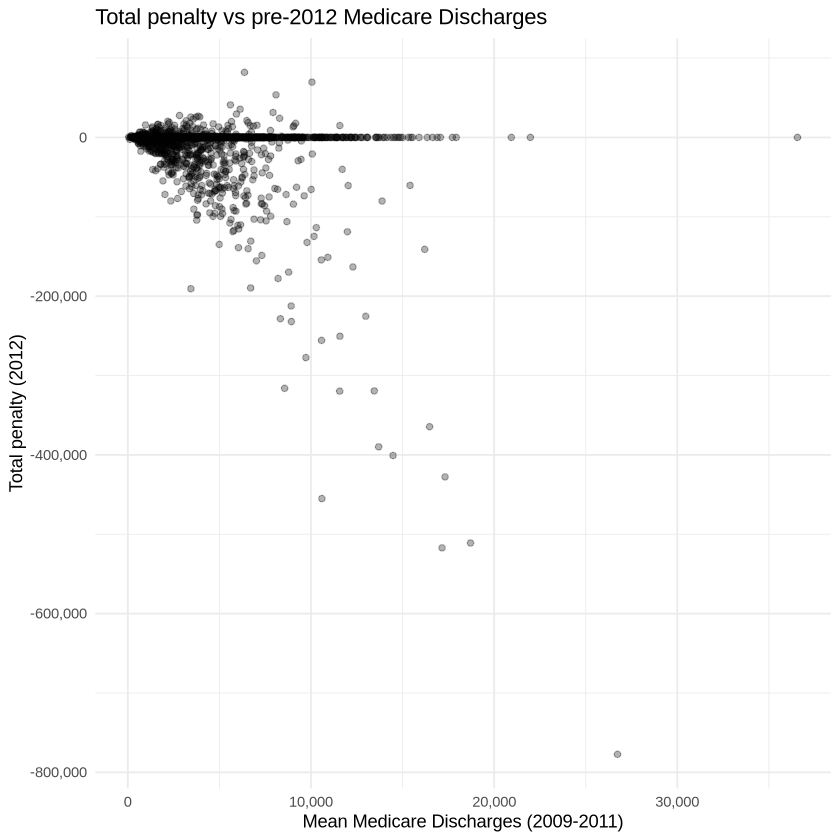

In [11]:
ggplot(merged_data, aes(x = mean_mcare, y = net_penalty)) +
  geom_point(alpha = 0.3) +
  scale_x_continuous(labels = scales::comma) +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Total penalty vs pre-2012 Medicare Discharges",
    x = "Mean Medicare Discharges (2009-2011)",
    y = "Total penalty (2012)"
  ) +
  theme_minimal()

The negative relationship between net penalty and pre-2012 Medicare discharges observed here signifies that the hospitals with a larger percentage of Medicare patients happen to receive larger penalties. 

## Problem 8

In [12]:
library(fixest)

# first stage - net_penalty ~ avg_mcare (instrument)
fs1 <- feols(net_penalty ~ mean_mcare, data = merged_data)
fs2 <- feols(net_penalty ~ mean_mcare + mean_beds, data = merged_data)
fs3 <- feols(net_penalty ~ mean_mcare + mean_beds + mean_mcaid, data = merged_data)

# reduced form - price_change ~ avg_mcare (instrument)
rf1 <- feols(price_change ~ mean_mcare, data = merged_data)
rf2 <- feols(price_change ~ mean_mcare + mean_beds, data = merged_data)
rf3 <- feols(price_change ~ mean_mcare + mean_beds + mean_mcaid, data = merged_data)

cat("=== First Stage ===\n")
summary(fs1)
summary(fs2)
summary(fs3)

cat("=== Reduced Form ===\n")
summary(rf1)
summary(rf2)
summary(rf3)


=== First Stage ===


OLS estimation, Dep. Var.: net_penalty
Observations: 2,393 
Standard-errors: IID 
              Estimate  Std. Error   t value   Pr(>|t|)    
(Intercept) 6132.04081 1168.888673   5.24604 1.6906e-07 ***
mean_mcare    -4.27677    0.242605 -17.62853  < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 37,210.7   Adj. R2: 0.114653

OLS estimation, Dep. Var.: net_penalty
Observations: 2,393 
Standard-errors: IID 
               Estimate  Std. Error    t value   Pr(>|t|)    
(Intercept) 6129.816492 1169.593461   5.240980 1.7371e-07 ***
mean_mcare    -4.278471    0.243947 -17.538504  < 2.2e-16 ***
mean_beds      0.033015    0.487568   0.067713 9.4602e-01    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 37,210.7   Adj. R2: 0.114284

OLS estimation, Dep. Var.: net_penalty
Observations: 2,393 
Standard-errors: IID 
               Estimate  Std. Error    t value   Pr(>|t|)    
(Intercept) 5568.751834 1180.319875   4.718002 2.5191e-06 ***
mean_mcare    -4.714863    0.278821 -16.910016  < 2.2e-16 ***
mean_beds     -0.008509    0.486793  -0.017479 9.8606e-01    
mean_mcaid     1.318409    0.410497   3.211743 1.3369e-03 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 37,130.6   Adj. R2: 0.117723

=== Reduced Form ===


OLS estimation, Dep. Var.: price_change
Observations: 2,393 
Standard-errors: IID 
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 172.393691  82.526683 2.08894 0.036818 *  
mean_mcare    0.022312   0.017129 1.30260 0.192835    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,627.2   Adj. R2: 2.912e-4

OLS estimation, Dep. Var.: price_change
Observations: 2,393 
Standard-errors: IID 
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 167.446133  82.497869 2.02970 0.042497 *  
mean_mcare    0.018536   0.017207 1.07724 0.281483    
mean_beds     0.073434   0.034391 2.13529 0.032839 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,624.7   Adj. R2: 0.001777

OLS estimation, Dep. Var.: price_change
Observations: 2,393 
Standard-errors: IID 
              Estimate Std. Error  t value   Pr(>|t|)    
(Intercept) 114.175447  83.108403  1.37381 1.6963e-01    
mean_mcare   -0.022898   0.019632 -1.16633 2.4360e-01    
mean_beds     0.069492   0.034276  2.02742 4.2730e-02 *  
mean_mcaid    0.125177   0.028904  4.33083 1.5468e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,614.4   Adj. R2: 0.009139

In [13]:
options(knitr.kable.NA = "")
library(knitr)
library(kableExtra)
library(fixest)

fmt   <- function(x, digits = 3) ifelse(is.na(x), NA_character_, formatC(x, format = "f", digits = digits))
fmt_p <- function(p) ifelse(is.na(p), NA_character_, sprintf("%.3f", p))

get_coef <- function(model, var) {
  cf <- coef(model)
  if (var %in% names(cf)) fmt(cf[var]) else NA_character_
}
get_p <- function(model, var) {
  s <- coef(summary(model))
  if (var %in% rownames(s)) fmt_p(s[var, "Pr(>|t|)"]) else NA_character_
}

data.frame(
  Statistic = c(
    "Intercept",                          "",
    "Avg Medicare",                       "",
    "Avg Beds (Pre-2012)",                "",
    "Avg Medicaid Discharges (Pre-2012)", "",
    "Num.Obs.", "R2"
  ),

  `FS 1` = c(
    get_coef(fs1, "(Intercept)"),  get_p(fs1, "(Intercept)"),
    get_coef(fs1, "mean_mcare"),   get_p(fs1, "mean_mcare"),
    NA, NA,
    NA, NA,
    as.character(nobs(fs1)),       fmt(r2(fs1)["r2"])
  ),
  `FS 2` = c(
    get_coef(fs2, "(Intercept)"),  get_p(fs2, "(Intercept)"),
    get_coef(fs2, "mean_mcare"),   get_p(fs2, "mean_mcare"),
    get_coef(fs2, "mean_beds"),    get_p(fs2, "mean_beds"),
    NA, NA,
    as.character(nobs(fs2)),       fmt(r2(fs2)["r2"])
  ),
  `FS 3` = c(
    get_coef(fs3, "(Intercept)"),  get_p(fs3, "(Intercept)"),
    get_coef(fs3, "mean_mcare"),   get_p(fs3, "mean_mcare"),
    get_coef(fs3, "mean_beds"),    get_p(fs3, "mean_beds"),
    get_coef(fs3, "mean_mcaid"),   get_p(fs3, "mean_mcaid"),
    as.character(nobs(fs3)),       fmt(r2(fs3)["r2"])
  ),

  `RF 1` = c(
    get_coef(rf1, "(Intercept)"),  get_p(rf1, "(Intercept)"),
    get_coef(rf1, "mean_mcare"),   get_p(rf1, "mean_mcare"),
    NA, NA,
    NA, NA,
    as.character(nobs(rf1)),       fmt(r2(rf1)["r2"])
  ),
  `RF 2` = c(
    get_coef(rf2, "(Intercept)"),  get_p(rf2, "(Intercept)"),
    get_coef(rf2, "mean_mcare"),   get_p(rf2, "mean_mcare"),
    get_coef(rf2, "mean_beds"),    get_p(rf2, "mean_beds"),
    NA, NA,
    as.character(nobs(rf2)),       fmt(r2(rf2)["r2"])
  ),
  `RF 3` = c(
    get_coef(rf3, "(Intercept)"),  get_p(rf3, "(Intercept)"),
    get_coef(rf3, "mean_mcare"),   get_p(rf3, "mean_mcare"),
    get_coef(rf3, "mean_beds"),    get_p(rf3, "mean_beds"),
    get_coef(rf3, "mean_mcaid"),   get_p(rf3, "mean_mcaid"),
    as.character(nobs(rf3)),       fmt(r2(rf3)["r2"])
  ),

  check.names    = FALSE,
  stringsAsFactors = FALSE
) %>%
  kable(
    col.names = c("", "FS 1", "FS 2", "FS 3", "RF 1", "RF 2", "RF 3"),
    align     = c("l", "r", "r", "r", "r", "r", "r"),
    booktabs  = TRUE,
    row.names = FALSE,
    caption   = "Table 2: First Stage and Reduced Form Estimates"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE) %>%
  row_spec(c(2, 4, 6, 8), italic = TRUE, color = "gray") %>%
  add_header_above(c(" " = 1, "First Stage" = 3, "Reduced Form" = 3)) %>%
  pack_rows("Coefficients", 1, 8) %>%
  pack_rows("Model Fit",    9, 10)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>Table 2: First Stage and Reduced Form Estimates</caption>
 <thead>
<tr>
<th style="empty-cells: hide;border-bottom:hidden;" colspan="1"></th>
<th style="border-bottom:hidden;padding-bottom:0; padding-left:3px;padding-right:3px;text-align: center; " colspan="3"><div style="border-bottom: 1px solid #ddd; padding-bottom: 5px; ">First Stage</div></th>
<th style="border-bottom:hidden;padding-bottom:0; padding-left:3px;padding-right:3px;text-align: center; " colspan="3"><div style="border-bottom: 1px solid #ddd; padding-bottom: 5px; ">Reduced Form</div></th>
</tr>
  <tr>
   <th style="text-align:left;font-weight: bold;">  </th>
   <th style="text-align:right;font-weight: bold;"> FS 1 </th>
   <th style="text-align:right;font-weight: bold;"> FS 2 </th>
   <th style="text-align:right;font-weight: bold;"> FS 3 </th>
   <th style="text-align:right;font-weight: bold;"> RF 1 </th>
   <th style="text-align:right;font-weig

We note that in the first stage, net penalty has the largest effect and most prominent statistical significance with average Medicare discharges, showing Medicare discharge as a good instrumental variable. Whereas in reduced form, there still exists a nonzero relationship with average Medicare discharges, thus, it holds though not vividly; rather, the specification with average beds recovers the most statistically significant p-value effect.

## Problem 9

In [14]:
# IV estimates - price_change ~ net_penalty, instrumented by avg_mcare
iv1 <- feols(price_change ~ 1 | net_penalty ~ mean_mcare, data = merged_data)
iv2 <- feols(price_change ~ mean_beds | net_penalty ~ mean_mcare, data = merged_data)
iv3 <- feols(price_change ~ mean_beds + mean_mcaid | net_penalty ~ mean_mcare, data = merged_data)

summary(iv1)
summary(iv2)
summary(iv3)


TSLS estimation, Dep. Var.: price_change, Endo.: net_penalty, Instr.: mean_mcare
Second stage: Dep. Var.: price_change
Observations: 2,393 
Standard-errors: IID 
                  Estimate Std. Error  t value  Pr(>|t|)    
(Intercept)     204.384322  65.799256  3.10618 0.0019175 ** 
fit_net_penalty  -0.005217   0.004002 -1.30372 0.1924540    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,624.9   Adj. R2: 0.002004
F-test (1st stage), net_penalty: stat = 310.8     , p < 2.2e-16 , on 1 and 2,391 DoF.
                     Wu-Hausman: stat =   0.177145, p = 0.673876, on 1 and 2,390 DoF.

TSLS estimation, Dep. Var.: price_change, Endo.: net_penalty, Instr.: mean_mcare
Second stage: Dep. Var.: price_change
Observations: 2,393 
Standard-errors: IID 
                  Estimate Std. Error  t value  Pr(>|t|)    
(Intercept)     194.002807  65.923255  2.94286 0.0032833 ** 
fit_net_penalty  -0.004332   0.004017 -1.07842 0.2809531    
mean_beds         0.073577   0.034340  2.14264 0.0322428 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,621.8   Adj. R2: 0.003976
F-test (1st stage), net_penalty: stat = 307.6    , p < 2.2e-16 , on 1 and 2,390 DoF.
                     Wu-Hausman: stat =   0.04458, p = 0.832796, on 1 and 2,389 DoF.

TSLS estimation, Dep. Var.: price_change, Endo.: net_penalty, Instr.: mean_mcare
Second stage: Dep. Var.: price_change
Observations: 2,393 
Standard-errors: IID 
                 Estimate Std. Error t value   Pr(>|t|)    
(Intercept)     87.130886  72.693923 1.19860 2.3080e-01    
fit_net_penalty  0.004856   0.004189 1.15921 2.4648e-01    
mean_beds        0.069533   0.034489 2.01610 4.3902e-02 *  
mean_mcaid       0.118774   0.026827 4.42748 9.9629e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,630.5   Adj. R2: -0.00306
F-test (1st stage), net_penalty: stat = 285.9    , p < 2.2e-16 , on 1 and 2,389 DoF.
                     Wu-Hausman: stat =   3.92007, p = 0.047828, on 1 and 2,388 DoF.

In [22]:
options(knitr.kable.NA = "")
library(knitr)
library(kableExtra)
library(fixest)

fmt   <- function(x, digits = 3) ifelse(is.na(x), NA_character_, formatC(x, format = "f", digits = digits))
fmt_p <- function(p) ifelse(is.na(p), NA_character_, sprintf("%.3f", p))

get_coef <- function(model, var) {
  cf <- coef(model)
  if (var %in% names(cf)) fmt(cf[var]) else NA_character_
}
get_p <- function(model, var) {
  s <- coef(summary(model))
  if (var %in% rownames(s)) fmt_p(s[var, "Pr(>|t|)"]) else NA_character_
}
get_fstat <- function(model) {
  fs <- fitstat(model, "ivf")$ivf1
  if (!is.null(fs)) fmt(fs$stat, 1) else NA_character_
}
get_wh <- function(model) {
  wh <- fitstat(model, "wh")$wh
  if (!is.null(wh)) fmt_p(wh$p) else NA_character_
}

data.frame(
  Statistic = c(
    "Intercept",                          "",
    "Net Penalty (fitted)",               "",
    "Avg Beds (Pre-2012)",                "",
    "Avg Medicaid Discharges (Pre-2012)", "",
    "Num.Obs.", "R2",
    "F-stat (1st stage)", "Wu-Hausman p"
  ),

  `IV 1` = c(
    get_coef(iv1, "(Intercept)"),       get_p(iv1, "(Intercept)"),
    get_coef(iv1, "fit_net_penalty"),   get_p(iv1, "fit_net_penalty"),
    NA, NA,
    NA, NA,
    as.character(nobs(iv1)),            fmt(r2(iv1)["r2"]),
    get_fstat(iv1),                     get_wh(iv1)
  ),
  `IV 2` = c(
    get_coef(iv2, "(Intercept)"),       get_p(iv2, "(Intercept)"),
    get_coef(iv2, "fit_net_penalty"),   get_p(iv2, "fit_net_penalty"),
    get_coef(iv2, "mean_beds"),         get_p(iv2, "mean_beds"),
    NA, NA,
    as.character(nobs(iv2)),            fmt(r2(iv2)["r2"]),
    get_fstat(iv2),                     get_wh(iv2)
  ),
  `IV 3` = c(
    get_coef(iv3, "(Intercept)"),       get_p(iv3, "(Intercept)"),
    get_coef(iv3, "fit_net_penalty"),   get_p(iv3, "fit_net_penalty"),
    get_coef(iv3, "mean_beds"),         get_p(iv3, "mean_beds"),
    get_coef(iv3, "mean_mcaid"),        get_p(iv3, "mean_mcaid"),
    as.character(nobs(iv3)),            fmt(r2(iv3)["r2"]),
    get_fstat(iv3),                     get_wh(iv3)
  ),

  check.names    = FALSE,
  stringsAsFactors = FALSE
) %>%
  kable(
    col.names = c("", "IV 1", "IV 2", "IV 3"),
    align     = c("l", "r", "r", "r"),
    booktabs  = TRUE,
    row.names = FALSE,
    caption   = "Table 3: IV (2SLS) Estimates of Net Penalty on Price Changes"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE) %>%
  row_spec(c(2, 4, 6, 8), italic = TRUE, color = "gray") %>%
  pack_rows("Coefficients", 1, 8) %>%
  pack_rows("Model Fit",    9, 10) %>%
  pack_rows("Diagnostics",  11, 12)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>Table 3: IV (2SLS) Estimates of Net Penalty on Price Changes</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;">  </th>
   <th style="text-align:right;font-weight: bold;"> IV 1 </th>
   <th style="text-align:right;font-weight: bold;"> IV 2 </th>
   <th style="text-align:right;font-weight: bold;"> IV 3 </th>
  </tr>
 </thead>
<tbody>
  <tr grouplength="8"><td colspan="4" style="border-bottom: 1px solid;"><strong>Coefficients</strong></td></tr>
<tr>
   <td style="text-align:left;font-weight: bold;padding-left: 2em;" indentlevel="1"> Intercept </td>
   <td style="text-align:right;"> 204.384 </td>
   <td style="text-align:right;"> 194.003 </td>
   <td style="text-align:right;"> 87.131 </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;font-style: italic;color: gray !important;padding-left: 2em;" indentlevel="1">  </td>
   <td style="text-align:right;font-style: italic;co

Here as well, we note that with no significant result in the first specification, the second specification with average beds becomes statistically significant, and maintains the same effect size in the third specification when included alongside average Medicaid discharges; however, yet again, average Medicaid discharges give the most prominent statistical significance with the largest effect size magnitude.

## Problem 10

LATE accounts for changes in the neighborhood of a policy decision and not throughout the context window. If a policy is implemented starting Year X, it would be misleading to include statistics of years prior to that, when such numbers would be unrelated. IV acts similarly to regression discontinuity in the sense that both give an essence of LATE. Thus, here, the overall ATE would be polluted by extrapolating too much beyond the policy or decision implementation period, thereby giving noisy or biased results. Here, IV finally captures LATE estimates of net penalties for price changes in hospitals that had penalized status from larger Medicare patient proportions. Thus, it would not be completely rational to extrapolate it to penalized hospitals that weren't subject to large Medicare patient intake.